In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, utils
from torchvision.utils import save_image
import matplotlib.pyplot as plt
import os
import numpy as np

# MNIST

In [ ]:
### 1. 데이터 준비 (MNIST 데이터셋 및 DataLoader) ###
# 목표: GAN을 학습시키기 위한 '진짜' 이미지 데이터를 준비하고,
#       모델이 학습하기 좋은 형태로 가공하여 공급하는 파이프라인을 구축합니다.

# DataLoader는 전체 데이터셋을 효율적으로 관리하고, 학습 시 지정된 크기(배치)만큼 데이터를 묶어서 전달하는 역할을 합니다.
dataloader = torch.utils.data.DataLoader(
    # datasets.MNIST: PyTorch에 내장된 MNIST 숫자 손글씨 데이터셋을 사용합니다.
    # './data/mnist': 데이터셋을 다운로드하거나 저장할 로컬 디렉토리 경로.
    # train=True: 학습용 데이터셋(60,000장)을 사용합니다.
    # download=True: 해당 경로에 데이터가 없으면 자동으로 다운로드합니다.
    datasets.MNIST('./data/mnist', train=True, download=True,

                   # transform: 다운로드한 원본 이미지에 적용할 전처리(preprocessing) 규칙들을 정의합니다.
                   # nn.Compose를 사용해 여러 단계의 변환을 순차적으로 실행합니다.
                   transform=transforms.Compose([
                       # transforms.Resize(28): 이미지 크기를 28x28로 조정합니다. (MNIST는 이미 28x28이라 사실상 변화 없음)
                       transforms.Resize(28),

                       # ★★★ 핵심 전처리 1 ★★★
                       # transforms.ToTensor():
                       # 1. PIL 이미지나 NumPy 배열 형태의 데이터를 PyTorch 텐서(Tensor)로 변환합니다.
                       # 2. 이미지 픽셀 값을 [0, 255] 범위에서 [0.0, 1.0] 범위로 자동 정규화합니다.
                       transforms.ToTensor(),

                       # ★★★ 핵심 전처리 2 ★★★
                       # transforms.Normalize([0.5], [0.5]):
                       # 텐서의 값을 특정 평균과 표준편차를 갖도록 정규화합니다.
                       # 수식: output = (input - 0.5) / 0.5
                       # [0.0, 1.0] 범위의 값을 [-1.0, 1.0] 범위로 변환합니다.
                       # 왜 이렇게 할까요? -> 생성자(Generator)의 마지막 활성화 함수가 Tanh()인데,
                       # Tanh()의 출력 범위가 [-1, 1]입니다. '진짜' 데이터와 '가짜' 데이터의 범위를 일치시켜
                       # 판별자(Discriminator)가 공정한 조건에서 비교하고 학습할 수 있도록 만들기 위함입니다.
                       transforms.Normalize([0.5], [0.5])
                   ])),
    # batch_size=64: 한 번에 64개의 이미지를 묶어서 모델에 전달합니다.
    batch_size=64,
    # shuffle=True: 매 에포크마다 데이터셋의 순서를 무작위로 섞어줍니다.
    #               모델이 데이터 순서에 과적합(overfitting)되는 것을 방지합니다.
    shuffle=True)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 14.5MB/s]


Extracting ./data/mnist/MNIST/raw/train-images-idx3-ubyte.gz to ./data/mnist/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 430kB/s]


Extracting ./data/mnist/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/mnist/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 3.51MB/s]


Extracting ./data/mnist/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/mnist/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 6.04MB/s]

Extracting ./data/mnist/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/mnist/MNIST/raw



In [ ]:
### 2. 생성자(Generator) 네트워크 정의 ###
# 역할: '위조지폐범' 또는 '화가'.
#       아무 의미 없는 무작위 노이즈(랜덤 숫자 벡터)를 입력받아,
#       그럴듯한 '가짜' 이미지를 생성(창조)하는 역할을 합니다.
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        # nn.Sequential을 사용하여 네트워크의 각 층을 순서대로 쌓아 모델을 구성합니다.
        self.model = nn.Sequential(
            # 입력: 100차원의 잠재 벡터 (latent vector, z)
            # nn.Linear(100, 256): 100개의 입력 뉴런을 256개의 출력 뉴런으로 변환합니다.
            #                     무작위 노이즈에 담긴 정보를 더 풍부한 특징으로 확장하는 시작점입니다.
            nn.Linear(100, 256),
            # nn.LeakyReLU(0.2): 활성화 함수. ReLU와 달리 음수 입력에 대해서도 작은 기울기(0.2)를 허용합니다.
            #                    GAN 학습 시 종종 발생하는 기울기 소실(vanishing gradient) 문제를 완화해 학습 안정성을 높여줍니다.
            nn.LeakyReLU(0.2),

            # 점차적으로 차원을 늘려가며 더 복잡하고 고차원적인 특징을 학습합니다. (256 -> 512 -> 1024)
            # 마치 화가가 대략적인 스케치에서 시작해 점점 디테일을 추가하는 과정과 같습니다.
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),

            # 최종 출력층: 1024개의 특징을 784개(28*28)의 픽셀 값으로 변환합니다.
            nn.Linear(1024, 28*28),

            # ★★★ 핵심 활성화 함수 ★★★
            # nn.Tanh(): 출력 값을 [-1, 1] 범위로 압축합니다.
            #            이는 위에서 '진짜' 이미지를 전처리하여 [-1, 1] 범위로 만든 것과 일치시키기 위함입니다.
            nn.Tanh()
        )

    def forward(self, z):
        # z: 입력으로 들어오는 100차원의 잠재 벡터(노이즈) 텐서.
        # self.model(z): z를 순차적으로 정의된 네트워크에 통과시켜 784개의 픽셀 값을 가진 벡터를 생성합니다.
        # .view(-1, 1, 28, 28): 1차원 벡터(784)를 [배치 크기, 채널 수, 높이, 너비] 형태의 이미지 텐서로 재구성합니다.
        #                      -1은 배치 크기를 자동으로 계산하라는 의미입니다.
        return self.model(z).view(-1, 1, 28, 28)

### 3. 판별자(Discriminator) 네트워크 정의 ###
# 역할: '경찰' 또는 '미술 평론가'.
#       이미지 한 장을 입력받아, 그 이미지가 데이터셋에 있는 '진짜'인지,
#       아니면 생성자가 만들어낸 '가짜'인지를 판별(구분)하는 역할을 합니다.
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            # 입력: 28*28 = 784차원의 이미지 벡터
            # nn.Linear(28*28, 1024): 784개의 픽셀 정보를 1024개의 고차원 특징으로 변환합니다.
            nn.Linear(28*28, 1024),
            nn.LeakyReLU(0.2),
            # nn.Dropout(0.3): 학습 과정에서 30%의 뉴런을 무작위로 비활성화합니다. (Regularization 기법)
            #                  판별자가 너무 똑똑해져서 생성자가 학습할 기회조차 얻지 못하는 상황을 방지하고,
            #                  과적합을 막아 모델의 일반화 성능을 높입니다.
            nn.Dropout(0.3),

            # 점차적으로 차원을 줄여가며 이미지의 핵심적인 특징을 요약합니다. (1024 -> 512 -> 256)
            # 마치 평론가가 작품의 전체적인 구성을 본 뒤, 세부적인 특징을 분석하여 최종 평가를 내리는 과정과 같습니다.
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            # 최종 출력층: 256개의 특징을 단 하나의 숫자(logit)로 압축합니다.
            nn.Linear(256, 1),

            # ★★★ 핵심 활성화 함수 ★★★
            # nn.Sigmoid(): 입력된 숫자를 0과 1 사이의 '확률' 값으로 변환합니다.
            #              이 확률 값은 이미지가 '진짜'일 확률을 의미합니다. (1에 가까울수록 진짜, 0에 가까울수록 가짜)
            nn.Sigmoid()
        )

    def forward(self, img):
        # img: 입력으로 들어오는 [배치 크기, 1, 28, 28] 크기의 이미지 텐서.
        # img.view(img.size(0), -1): 2D 이미지 텐서를 1D 벡터로 평탄화(flatten)합니다.
        #                            [64, 1, 28, 28] -> [64, 784]
        img_flat = img.view(img.size(0), -1)
        # 평탄화된 이미지를 모델에 통과시켜 최종 판별 결과(확률)를 얻습니다.
        return self.model(img_flat)

In [ ]:
### 1. 학습 환경 설정 ###
# ==========================================================================================

# 장치 설정: GPU(cuda)를 사용할 수 있으면 GPU를 사용하고, 그렇지 않으면 CPU를 사용합니다.
# 대규모 연산이 필요한 딥러닝에서는 GPU 사용이 거의 필수적입니다.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 생성자(Generator)와 판별자(Discriminator) 객체를 생성하고, 설정된 장치(device)로 보냅니다.
generator = Generator().to(device)
discriminator = Discriminator().to(device)

# 옵티마이저(Optimizer) 설정: 생성자와 판별자를 위한 별도의 Adam 옵티마이저를 생성합니다.
# GAN 학습에서는 두 네트워크가 서로 다른 목표를 가지고 독립적으로 학습하기 때문에,
# 각각의 파라미터를 업데이트할 별도의 '트레이너'가 필요합니다.
# lr=0.0002, betas=(0.5, 0.999): 이 값들은 DCGAN 논문에서 제안된, 안정적인 GAN 학습에 효과적이라고 알려진 하이퍼파라미터입니다.
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

# 손실 함수(Loss Function) 정의: Binary Cross Entropy Loss를 사용합니다.
# 이진 분류 문제(진짜 vs 가짜)에 적합한 손실 함수로, 판별자의 예측 확률이 정답(진짜=1, 가짜=0)과 얼마나 다른지를 측정합니다.
criterion = nn.BCELoss()

# 총 학습 에포크 수 설정
num_epochs = 100

# 평가용 고정 노이즈 벡터 생성:
# 매 에포크마다 동일한 노이즈를 사용하여 이미지를 생성하면,
# 학습이 진행됨에 따라 생성된 이미지가 어떻게 점진적으로 개선되는지 일관성 있게 비교하고 관찰할 수 있습니다.
fixed_noise = torch.randn(64, 100, device=device)

# 생성된 이미지와 판별 결과를 저장할 폴더를 생성합니다.
# exist_ok=True: 폴더가 이미 존재하면 오류를 발생시키지 않고 넘어갑니다.
os.makedirs('./images', exist_ok=True)
os.makedirs('./results', exist_ok=True)


### 2. GAN 학습 루프 (Training Loop) ###
# ==========================================================================================
# 지금부터 '에포크(epoch)'라는 단위로 전체 학습 과정을 반복하는 거대한 루프를 시작합니다.
# 1 에포크란, 준비된 전체 훈련 데이터셋(MNIST 60,000장)을 모두 한 번씩 사용하여 모델을 훈련시키는 한 사이클을 의미합니다.
# 이 과정을 여러 번(여기서는 100번) 반복하며 생성자와 판별자의 성능을 점진적으로 향상시킵니다.
for epoch in range(num_epochs):
    # --- [에포크 시작] ---
    # 현재 에포크 번호를 콘솔에 출력하여 진행 상황을 알립니다.
    # print(f"--- Epoch {epoch+1}/{num_epochs} 시작 ---")

    # [메모리 상태]: 모델의 가중치들은 이전 에포크에서 학습된 상태를 유지하고 있습니다.

    # [명령 1]: 생성자와 판별자 모델에게 "지금부터 훈련 모드(training mode)에 돌입한다"고 선언합니다.
    # [내부 동작]: 모델 내부에 있는 모든 모듈(레이어)에 대해 .train() 메소드가 호출됩니다.
    #             특히 Dropout 레이어는 활성화되고, BatchNorm 레이어는 현재 배치의 통계량을 사용하여 정규화를 수행하도록 설정됩니다.
    #             이는 모델이 훈련 데이터에 적응하며 파라미터를 업데이트할 준비를 갖추게 합니다.
    generator.train()
    discriminator.train()

    # [명령 2]: 이번 에포크 동안의 각종 통계치(손실, 점수)를 기록하기 위한 변수들을 0으로 초기화합니다.
    # [메모리 상태]: total_d_loss, total_g_loss 등의 변수들이 float 0.0으로 메모리에 할당됩니다.
    #               이들은 각 미니배치에서 계산된 값을 계속 더해나갈 누적기(accumulator) 역할을 합니다.
    total_d_loss = 0.0
    total_g_loss = 0.0
    total_real_score = 0.0
    total_fake_score = 0.0
    num_batches = 0

    # --- [미니배치 루프 시작] ---
    # [명령 3]: DataLoader에게 "훈련 데이터셋에서 데이터를 한 묶음(미니배치, 여기서는 64장)씩 꺼내줘"라고 요청합니다.
    # [내부 동작]: DataLoader는 전체 60,000장의 데이터를 무작위로 섞은 뒤(shuffle=True), 64장씩 잘라 순서대로 제공합니다.
    #             이 for 루프는 전체 데이터셋을 모두 사용할 때까지 (60000 / 64)회 반복됩니다.
    for real_images, _ in dataloader:
        # [현재 상태]: real_images 텐서(크기: [64, 1, 28, 28])와 labels 텐서(크기: [64])가 CPU 메모리에 로드되었습니다.

        num_batches += 1
        # [명령 4]: 현재 배치의 실제 이미지 개수(batch_size)를 확인합니다.
        # [내부 동작]: real_images 텐서의 0번째 차원 크기를 읽어옵니다. (보통 64, 마지막 배치는 더 작을 수 있음)
        batch_size = real_images.size(0)

        # [명령 5]: 손실 계산에 사용할 '정답' 레이블 텐서를 생성합니다.
        # [내부 동작]:
        # 1. torch.ones: '진짜' 이미지를 의미하는 숫자 1로 채워진 [batch_size, 1] 크기의 텐서를 생성합니다.
        # 2. torch.zeros: '가짜' 이미지를 의미하는 숫자 0으로 채워진 [batch_size, 1] 크기의 텐서를 생성합니다.
        # 3. .to(device): 생성된 텐서들을 CPU 메모리에서 GPU 메모리로 복사합니다. (이후 연산을 GPU에서 수행하기 위함)
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # ----------------------------------------------------------------------
        # (1단계) 경찰 훈련: 판별자(Discriminator) 학습
        # 목표: 진짜 지폐와 위조지폐를 더 잘 구별하는 능력을 키운다.
        # ----------------------------------------------------------------------

        # [명령 6]: 판별자의 옵티마이저(optimizer_D)에게 "이전 계산에서 누적된 모든 기울기 값을 0으로 리셋하라"고 지시합니다.
        # [내부 동작]: 판별자 네트워크의 모든 파라미터(가중치, 편향)에 연결된 .grad 속성을 None 또는 0으로 설정합니다.
        # [이유]: PyTorch는 기울기를 새로 계산할 때마다 덮어쓰는 것이 아니라 '누적'하기 때문에,
        #         현재 미니배치에 대한 정확한 기울기를 계산하려면 이전 배치의 잔여 기울기를 반드시 초기화해야 합니다.
        discriminator.zero_grad()

        # === 1-1. 진짜 이미지에 대한 훈련: "이것이 진짜다"라고 배우는 과정 ===

        # [명령 7]: 진짜 이미지(real_images)를 판별자에게 보여주고, 이것이 진짜일 확률을 예측하게 합니다.
        # [내부 동작]:
        # 1. real_images.to(device): 진짜 이미지 텐서를 GPU로 복사합니다.
        # 2. discriminator(...): 복사된 이미지 텐서가 판별자 네트워크를 통과(순전파)합니다.
        # 3. 최종적으로 Sigmoid를 거쳐 0과 1 사이의 확률 값으로 구성된 [batch_size, 1] 크기의 텐서(outputs_real)가 출력됩니다.
        outputs_real = discriminator(real_images.to(device))

        # [명령 8]: 판별자의 예측(outputs_real)과 정답(real_labels, 즉 1)이 얼마나 다른지 손실(d_loss_real)을 계산합니다.
        # [내부 동작]: BCELoss 함수가 두 텐서 간의 차이를 계산하여 스칼라 값인 손실을 반환합니다. 예측이 1에 가까울수록 손실은 작아집니다.
        d_loss_real = criterion(outputs_real, real_labels)

        # [명령 9]: 판별자가 진짜 이미지를 진짜라고 판단한 평균 확률(real_score)을 기록합니다. (성능 모니터링용)
        # [내부 동작]: .mean()으로 평균을 구하고, .item()으로 텐서에서 순수 숫자 값만 추출합니다.
        real_score = outputs_real.mean().item()

        # === 1-2. 가짜 이미지에 대한 훈련: "이런 것이 가짜다"라고 배우는 과정 ===

        # [명령 10]: 위조지폐를 만들 재료, 즉 100차원의 무작위 노이즈 벡터를 생성합니다.
        # [내부 동작]: torch.randn이 평균 0, 표준편차 1의 정규분포에서 [batch_size, 100] 크기의 난수 텐서를 생성하여 GPU에 할당합니다.
        noise = torch.randn(batch_size, 100, device=device)

        # [명령 11]: 생성자에게 노이즈를 주어 가짜 이미지를 만들게 합니다.
        # [내부 동작]: 노이즈 텐서가 생성자 네트워크를 통과(순전파)하여, [-1, 1] 범위의 픽셀 값을 갖는
        #             [batch_size, 1, 28, 28] 크기의 가짜 이미지 텐서(fake_images)를 생성합니다.
        fake_images = generator(noise)

        # [명령 12]: 생성된 가짜 이미지를 판별자에게 보여주고, 이것이 진짜일 확률을 예측하게 합니다.
        # ★★★ [매우 중요한 내부 동작]: .detach() ★★★
        # [현재 상황]: fake_images 텐서는 생성자의 연산 기록(계산 그래프)을 가지고 있습니다.
        # [명령의 의미]: .detach()는 이 연산 기록을 '분리(detach)'하여, fake_images를 그래디언트가 흐르지 않는 단순 데이터 텐서로 만듭니다.
        # [이유]: 지금은 '판별자'만 훈련시키는 시간입니다. 만약 detach()를 하지 않으면, 이후 d_loss.backward()가 호출될 때
        #         판별자의 손실로부터 계산된 그래디언트가 판별자를 거슬러 올라가 '생성자'의 파라미터에까지 전달됩니다.
        #         이는 우리가 의도하지 않은 생성자의 업데이트를 유발하므로, detach()로 이 흐름을 차단해야 합니다.
        outputs_fake = discriminator(fake_images.detach())

        # [명령 13]: 판별자의 예측(outputs_fake)과 정답(fake_labels, 즉 0)이 얼마나 다른지 손실(d_loss_fake)을 계산합니다.
        # [내부 동작]: 예측이 0에 가까울수록 손실은 작아집니다.
        d_loss_fake = criterion(outputs_fake, fake_labels)
        fake_score = outputs_fake.mean().item()

        # === 1-3. 판별자 최종 업데이트 ===

        # [명령 14]: 진짜 손실과 가짜 손실을 합산하여 판별자의 최종 손실(d_loss)을 계산합니다.
        d_loss = d_loss_real + d_loss_fake

        # [명령 15]: "d_loss를 줄이기 위해 판별자의 모든 파라미터들을 어떻게 바꿔야 하는가?"에 대한 해답, 즉 그래디언트를 계산하라.
        # [내부 동작]: PyTorch의 자동 미분 엔진이 d_loss에서부터 시작하여 계산 그래프를 거꾸로 거슬러 올라가며,
        #             판별자 네트워크의 모든 파라미터(가중치, 편향)에 대한 편미분 값(그래디언트)을 계산하여 각 파라미터의 .grad 속성에 저장합니다.
        #             (fake_images.detach() 덕분에 이 과정은 생성자에게 영향을 주지 않습니다.)
        d_loss.backward()

        # [명령 16]: "계산된 그래디언트를 바탕으로 판별자의 파라미터들을 실제로 업데이트하라."
        # [내부 동작]: optimizer_D가 자신이 관리하는 판별자의 파라미터들의 .grad 값을 읽고,
        #             Adam 최적화 알고리즘에 따라 각 파라미터 값을 수정(업데이트)합니다.
        optimizer_D.step()

        # ----------------------------------------------------------------------
        # (2단계) 위조지폐범 훈련: 생성자(Generator) 학습
        # 목표: 더 똑똑해진 경찰을 속일 수 있을 만큼 더 정교한 위조지폐를 만든다.
        # ----------------------------------------------------------------------

        # [명령 17]: 생성자의 옵티마이저(optimizer_G)에게 "이전 기울기 값을 0으로 리셋하라"고 지시합니다.
        generator.zero_grad()

        # [명령 18]: 새로운 가짜 이미지를 생성하고, 방금 막 더 똑똑해진 판별자에게 평가를 받습니다.
        noise2 = torch.randn(batch_size, 100, device=device)
        fake_images2 = generator(noise2)

        # [명령 19]: 판별자가 새로운 가짜 이미지를 판별하게 합니다.
        # [내부 동작]: 이번에는 .detach()를 사용하지 않습니다.
        # [이유]: 생성자를 훈련시키려면, 판별자의 판별 결과(손실)로부터 계산된 그래디언트가 판별자를 거쳐
        #         '생성자'의 파라미터까지 온전히 전달되어야 합니다. 여기서 계산 그래프가 끊기면 안 됩니다.
        #         (단, 판별자의 파라미터는 optimizer_G의 관리 대상이 아니므로 업데이트되지 않습니다.)
        outputs = discriminator(fake_images2)

        # [명령 20]: "생성자가 판별자를 완벽히 속였다면, 판별자의 출력(outputs)이 1(real_labels)이 나왔을 것이다."
        #            라는 가정 하에 손실(g_loss)을 계산합니다.
        # [핵심 아이디어]: 생성자의 목표는 판별자를 속여서 자신의 가짜 이미지를 '진짜'라고 믿게 만드는 것입니다.
        #                 따라서 생성자의 손실은, 판별자의 출력이 1에서 얼마나 멀리 떨어져 있는지를 측정합니다.
        g_loss = criterion(outputs, real_labels)

        # [명령 21]: g_loss를 줄이기 위해 '생성자'의 파라미터들을 어떻게 바꿔야 하는지 그래디언트를 계산하라.
        # [내부 동작]: g_loss에서부터 시작하여 계산 그래프를 거꾸로 거슬러 올라갑니다.
        #             그래디언트는 판별자 네트워크를 통과한 뒤(이때 판별자 파라미터의 그래디언트도 계산되지만 무시됨),
        #             최종적으로 생성자 네트워크의 모든 파라미터의 .grad 속성에 저장됩니다.
        g_loss.backward()

        # [명령 22]: 계산된 그래디언트를 바탕으로 '생성자'의 파라미터들을 실제로 업데이트하라.
        # [내부 동작]: optimizer_G는 자신이 관리하는 생성자의 파라미터들만 업데이트합니다.
        optimizer_G.step()

        # [명령 23]: 이번 미니배치에서 계산된 통계치들을 에포크 전체 통계 변수에 누적합니다.
        total_d_loss += d_loss.item()
        total_g_loss += g_loss.item()
        total_real_score += real_score
        total_fake_score += fake_score

    # --- [미니배치 루프 종료] ---

    # [명령 24]: 한 에포크 동안 누적된 통계치들의 평균을 계산합니다.
    avg_d_loss = total_d_loss / num_batches
    avg_g_loss = total_g_loss / num_batches
    avg_real_score = total_real_score / num_batches
    avg_fake_score = total_fake_score / num_batches

    # [명령 25]: 계산된 평균 통계치들을 콘솔에 출력하여 학습 진행 상황을 사용자에게 알립니다.
    print(f"Epoch [{epoch+1}/{num_epochs}]: d_loss={avg_d_loss:.4f}, g_loss={avg_g_loss:.4f}, "
          f"D(x)={avg_real_score:.2f}, D(G(z))={avg_fake_score:.2f}")

    # ----------------------------------------------------------------------
    # (3단계) 중간 평가 및 결과 저장
    # ----------------------------------------------------------------------

    # [명령 26]: 모델들을 "평가 모드(evaluation mode)"로 전환합니다.
    # [내부 동작]: Dropout 레이어가 비활성화됩니다.
    generator.eval()
    discriminator.eval()

    # [명령 27]: 지금부터는 그래디언트 계산을 일시 중지합니다. (메모리 절약, 속도 향상)
    with torch.no_grad():
        # [명령 28]: 학습 시작 전에 미리 만들어둔 '고정된 노이즈(fixed_noise)'를 생성자에게 주어 이미지를 생성합니다.
        # [이유]: 매번 동일한 노이즈로 생성된 이미지를 저장하면, 에포크가 진행됨에 따라 생성 품질이 어떻게 변하는지
        #         일관성 있게 추적할 수 있습니다.
        fake_images = generator(fixed_noise)

        # [명령 29]: 생성된 이미지 묶음을 하나의 이미지 파일로 저장합니다.
        save_image(fake_images, f'./images/fake_images_epoch_{epoch+1:04d}.png', normalize=True)

        # [명령 30]: 고정 노이즈로 만든 이미지에 대한 판별자의 평가(진짜일 확률) 결과를 NumPy 파일로 저장합니다.
        discriminator_outputs = discriminator(fake_images).cpu().detach().numpy().reshape(8, 8)
        np.save(f'./results/discriminator_outputs_epoch_{epoch+1:04d}.npy', discriminator_outputs)

# --- [에포크 루프 종료] ---
print('Training finished.')

Epoch [1/100]: d_loss=0.7263, g_loss=2.5348, D(x)=0.81, D(G(z))=0.30
Epoch [2/100]: d_loss=0.4801, g_loss=3.3272, D(x)=0.86, D(G(z))=0.15
Epoch [3/100]: d_loss=0.4046, g_loss=2.8718, D(x)=0.88, D(G(z))=0.12
Epoch [4/100]: d_loss=0.4726, g_loss=2.5243, D(x)=0.86, D(G(z))=0.14
Epoch [5/100]: d_loss=0.6077, g_loss=2.2043, D(x)=0.81, D(G(z))=0.19
Epoch [6/100]: d_loss=0.7691, g_loss=1.8152, D(x)=0.75, D(G(z))=0.25
Epoch [7/100]: d_loss=0.8999, g_loss=1.5269, D(x)=0.71, D(G(z))=0.30
Epoch [8/100]: d_loss=0.9605, g_loss=1.4105, D(x)=0.68, D(G(z))=0.32
Epoch [9/100]: d_loss=0.9759, g_loss=1.3851, D(x)=0.68, D(G(z))=0.33
Epoch [10/100]: d_loss=1.0004, g_loss=1.3402, D(x)=0.67, D(G(z))=0.34
Epoch [11/100]: d_loss=1.0261, g_loss=1.2945, D(x)=0.66, D(G(z))=0.35
Epoch [12/100]: d_loss=1.0432, g_loss=1.2614, D(x)=0.65, D(G(z))=0.35
Epoch [13/100]: d_loss=1.0572, g_loss=1.2411, D(x)=0.65, D(G(z))=0.36
Epoch [14/100]: d_loss=1.0651, g_loss=1.2054, D(x)=0.64, D(G(z))=0.36
Epoch [15/100]: d_loss=1.0869

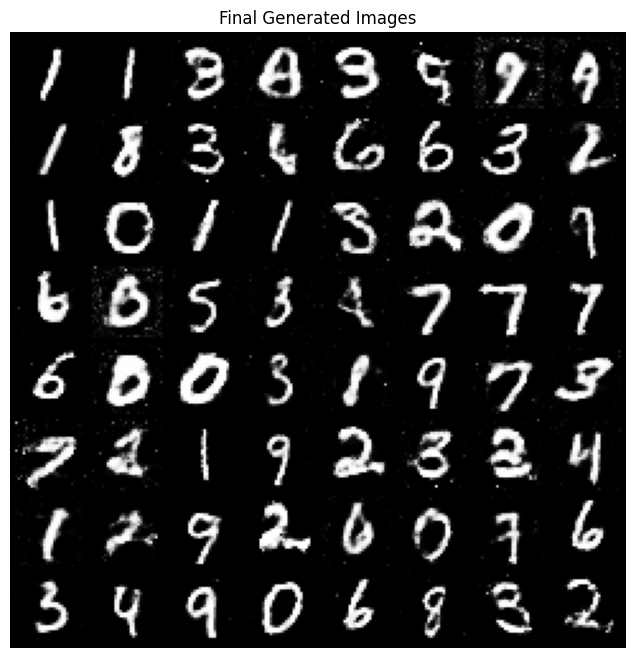

In [ ]:
### 마지막 에포크에서 생성된 이미지 그리드 출력 ###
# 이 코드의 목표: "치열한 경쟁을 통해 마침내 '화가'가 된 생성자가 그린 최종 작품들을 감상해 보자!"

# ==========================================================================================
# 1. 최종 이미지 생성 및 준비
# ==========================================================================================

# torch.no_grad() 컨텍스트 매니저를 사용하여 기울기 계산을 비활성화합니다.
# 이미 학습이 끝난 모델을 사용해 결과만 생성하는 과정이므로, 기울기 계산이 전혀 필요 없습니다.
with torch.no_grad():
    # --- 학습된 생성자를 이용해 최종 이미지 생성 ---
    # generator(fixed_noise): 학습 과정 내내 비교용으로 사용했던 '고정된 노이즈(fixed_noise)'를
    #                         최종적으로 학습된 생성자 모델에 입력하여 64개의 '가짜' 이미지를 생성합니다.
    # .detach(): 생성된 텐서를 현재의 계산 그래프(computation graph)로부터 분리합니다.
    #            메모리를 효율적으로 관리하고, 이후 NumPy 변환 등 PyTorch 외부 라이브러리와의 연동을 원활하게 합니다.
    # .cpu(): 만약 생성된 이미지가 GPU에 있다면, 시각화 라이브러리(Matplotlib)가 처리할 수 있도록 CPU로 이동시킵니다.
    fake_images = generator(fixed_noise).detach().cpu()

# ==========================================================================================
# 2. 이미지 그리드 생성 및 시각화
# ==========================================================================================

# --- 여러 이미지를 하나의 큰 이미지로 합치기 ---
# utils.make_grid(): PyTorch Vision 라이브러리가 제공하는 매우 유용한 함수입니다.
#                    여러 개의 이미지 텐서 묶음(배치)을 받아서 하나의 이미지 그리드로 깔끔하게 정렬해 줍니다.
# fake_images: 위에서 생성한 64개의 이미지 묶음 텐서.
# nrow=8: 그리드의 한 행(row)에 8개의 이미지를 배치하라는 의미입니다.
#         총 64개의 이미지이므로, 결과적으로 8x8 크기의 그리드가 생성됩니다.
# normalize=True: 이미지 텐서의 픽셀 값 범위를 [0.0, 1.0]으로 자동으로 정규화하여,
#                 이미지가 정상적으로 보이도록 만듭니다. (원본 이미지는 [-1, 1] 범위였음)
grid = utils.make_grid(fake_images, nrow=8, normalize=True)

# --- Matplotlib을 이용해 최종 이미지 그리드 출력 ---

# 시각화할 그림(figure)의 크기를 가로 8인치, 세로 8인치로 설정합니다.
plt.figure(figsize=(8,8))

# ★★★ 핵심: 차원 순서 변경 ★★★
# plt.imshow() 함수를 사용하여 이미지 그리드를 화면에 표시합니다.
#
# np.transpose(grid, (1, 2, 0)):
# PyTorch의 이미지 텐서는 (채널, 높이, 너비) 즉 (C, H, W) 순서로 차원을 가집니다.
# 하지만 Matplotlib의 imshow 함수는 (높이, 너비, 채널) 즉 (H, W, C) 순서의 데이터를 기대합니다.
# np.transpose 함수는 이 차원의 순서를 바꿔주는 역할을 합니다.
# (0, 1, 2) 순서의 차원을 (1, 2, 0) 순서로 재배열 -> (C, H, W) -> (H, W, C)
# 이 변환 과정이 없으면 이미지가 깨져서 보입니다.
plt.imshow(np.transpose(grid, (1, 2, 0)))

# 그림의 제목을 설정합니다.
plt.title('Final Generated Images')

# 이미지의 축(눈금, 레이블 등)을 제거하여 이미지만 깔끔하게 보이도록 합니다.
plt.axis('off')

# 최종적으로 완성된 그림을 화면에 출력합니다.
plt.show()